Rodrigo Romay Aba

Ainhoa de Diego Silva

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Lambda, Dense
from sklearn.metrics.pairwise import cosine_similarity
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

Lectura del dataset y tokenización



In [ ]:
ruta_archivo = os.path.join('datasets', 'game_of_thrones.txt') 

# Leemos el archivo completo
with open(ruta_archivo, 'r', encoding='utf-8') as f:
    texto_corpus = f.read()

print("Entrenando el Tokenizador...")
tokenizer = Tokenizer()
# Keras espera una lista de textos
tokenizer.fit_on_texts([texto_corpus])

# Transformamos todo el texto en una lista plana de IDs numéricos
secuencia_ids = tokenizer.texts_to_sequences([texto_corpus])[0]

# El tamaño del vocabulario (sumamos 1 por si necesitas padding o por el index 0 reservado de Keras) [cite: 485]
vocab_size = len(tokenizer.word_index) + 1 
print(f"Tamaño del vocabulario: {vocab_size}")
print(f"Total de palabras en el texto: {len(secuencia_ids)}")

Creacion de muestras

In [5]:
def generar_muestras_cbow(secuencia, window_size=2):
    entradas_contexto = []
    salidas_objetivo = []
    
    # Recorremos la secuencia respetando los márgenes de la ventana para no salirnos de los índices
    for i in range(window_size, len(secuencia) - window_size):
        # Obtenemos las palabras de la izquierda y la derecha [cite: 257]
        contexto_izq = secuencia[i - window_size : i]
        contexto_der = secuencia[i + 1 : i + window_size + 1]
        
        # Unimos el contexto excluyendo la palabra central
        contexto = contexto_izq + contexto_der
        palabra_central = secuencia[i]
        
        entradas_contexto.append(contexto)
        salidas_objetivo.append(palabra_central)
        
    return np.array(entradas_contexto), np.array(salidas_objetivo)

# Generamos las muestras con un tamaño de ventana de 2 (2 palabras a la izq y 2 a la der) [cite: 257]
print("Generando muestras para CBOW...")
X_cbow, y_cbow = generar_muestras_cbow(secuencia_ids, window_size=2)

print(f"Forma de las entradas CBOW (X): {X_cbow.shape}") # Debería ser (n_muestras, window_size * 2)
print(f"Forma de las salidas CBOW (y): {y_cbow.shape}")  # Debería ser (n_muestras,)

Generando muestras para CBOW...
Forma de las entradas CBOW (X): (108205, 4)
Forma de las salidas CBOW (y): (108205,)


Creacion del modelo CBOW

In [6]:
print("\nConstruyendo el modelo CBOW...")

# Hiperparámetros
embedding_size = 100  # Tamaño del vector (suele ser entre 50 y 300)
context_length = 4    # 2 palabras a la izquierda + 2 a la derecha

# a. Capa de entrada
entrada = Input(shape=(context_length,), name='entrada_contexto')

# b. Capa de Embeddings [cite: 31, 306]
# Esta capa mapea los IDs a vectores.
capa_embedding = Embedding(input_dim=vocab_size, 
                           output_dim=embedding_size, 
                           name='capa_embedding')(entrada)

# c. Capa oculta: Media de los embeddings
# Promedia los 4 vectores del contexto en un único vector.
media_vectores = Lambda(lambda x: K.mean(x, axis=1), name='media_vectores')(capa_embedding)

# d. Capa de salida [cite: 34, 308]
# Genera predicciones con softmax para encontrar la palabra objetivo.
salida = Dense(vocab_size, activation='softmax', name='salida_palabra')(media_vectores)

# Definimos y compilamos el modelo
modelo_cbow = Model(inputs=entrada, outputs=salida)
modelo_cbow.compile(loss='sparse_categorical_crossentropy', 
                    optimizer='adam', 
                    metrics=['accuracy']) # Usamos accuracy para evaluar si acierta la palabra [cite: 397]

modelo_cbow.summary()


Construyendo el modelo CBOW...



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_contexto (InputLayer)   │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_embedding (Embedding)      │ (None, 4, 100)         │       747,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ media_vectores (Lambda)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_palabra (Dense)          │ (None, 7479)           │       755,379 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,503,279 (5.73 MB)

 Trainable params: 1,503,279 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo CBOW

In [7]:
print("\nIniciando el entrenamiento...")
# La guía sugiere empezar con un batch_size de 128
# Usamos un validation_split para usar un conjunto de desarrollo para evaluar [cite: 36]
historial = modelo_cbow.fit(X_cbow, 
                            y_cbow, 
                            batch_size=128, 
                            epochs=5, 
                            validation_split=0.1)

# ==========================================
# 6. EXTRACCIÓN DE LOS EMBEDDINGS
# ==========================================
# Una vez entrenado, sacamos los vectores resultantes
pesos_embeddings = modelo_cbow.get_layer('capa_embedding').get_weights()[0]
print(f"\nForma final de la matriz de embeddings: {pesos_embeddings.shape}")


Iniciando el entrenamiento...
Epoch 1/5
761/761 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.0615 - loss: 7.1094 - val_accuracy: 0.0709 - val_loss: 6.8819
Epoch 2/5
761/761 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.0713 - loss: 6.4056 - val_accuracy: 0.0793 - val_loss: 6.7135
Epoch 3/5
761/761 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.0817 - loss: 6.1930 - val_accuracy: 0.0870 - val_loss: 6.6111
Epoch 4/5
761/761 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.0949 - loss: 6.0012 - val_accuracy: 0.0957 - val_loss: 6.5249
Epoch 5/5
761/761 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.1100 - loss: 5.8102 - val_accuracy: 0.1065 - val_loss: 6.4543

Forma final de la matriz de embeddings: (7479, 100)


Evaluación cualitativa del modelo CBOW

In [8]:
print("\n--- Evaluando Similitud Semántica ---")

# Invertimos el diccionario para poder buscar palabras a partir de su ID
index_word = {id: palabra for palabra, id in tokenizer.word_index.items()}

def obtener_palabras_similares(palabra_objetivo, matriz_embeddings, top_n=10):
    # Comprobamos si la palabra está en nuestro vocabulario
    if palabra_objetivo not in tokenizer.word_index:
        print(f"La palabra '{palabra_objetivo}' no está en el vocabulario.")
        return
    
    # Obtenemos el ID y el vector de la palabra objetivo
    word_id = tokenizer.word_index[palabra_objetivo]
    word_vector = matriz_embeddings[word_id].reshape(1, -1)
    
    # Calculamos la similitud del coseno de este vector contra TODOS los demás vectores del vocabulario [cite: 478]
    similitudes = cosine_similarity(word_vector, matriz_embeddings)[0]
    
    # Obtenemos los índices de las palabras con mayor similitud (de mayor a menor)
    # Excluimos el índice 0 (que es la propia palabra objetivo, que tendrá similitud 1.0)
    indices_top = np.argsort(similitudes)[::-1][1:top_n+1]
    
    print(f"\nLas {top_n} palabras más similares a '{palabra_objetivo}':")
    for idx in indices_top:
        # El index_word empieza en 1 (Keras reserva el 0)
        if idx in index_word:
            print(f" - {index_word[idx]} (Similitud: {similitudes[idx]:.4f})")

# Vamos a probar con un par de palabras clásicas de Game of Thrones
# (Puedes cambiar estas palabras por las que estén en tu archivo .txt)
palabras_prueba = ["betray", "ambitious", "sword", "wall"]

for palabra in palabras_prueba:
    obtener_palabras_similares(palabra, pesos_embeddings, top_n=10)


--- Evaluando Similitud Semántica ---

Las 10 palabras más similares a 'betray':
 - braced (Similitud: 0.9410)
 - digest (Similitud: 0.9388)
 - happy (Similitud: 0.9373)
 - defended (Similitud: 0.9371)
 - scares (Similitud: 0.9370)
 - dice (Similitud: 0.9342)
 - allow (Similitud: 0.9339)
 - stays (Similitud: 0.9334)
 - interrupt (Similitud: 0.9321)
 - remind (Similitud: 0.9313)

Las 10 palabras más similares a 'ambitious':
 - revolt (Similitud: 0.8560)
 - several (Similitud: 0.8436)
 - harder (Similitud: 0.8384)
 - eight (Similitud: 0.8354)
 - lesser (Similitud: 0.8307)
 - mine (Similitud: 0.8306)
 - none (Similitud: 0.8303)
 - somewhat (Similitud: 0.8290)
 - course (Similitud: 0.8269)
 - loathing (Similitud: 0.8231)

Las 10 palabras más similares a 'sword':
 - horse (Similitud: 0.9374)
 - head (Similitud: 0.9349)
 - garron (Similitud: 0.9226)
 - mouth (Similitud: 0.9221)
 - arm (Similitud: 0.9195)
 - cheek (Similitud: 0.9175)
 - helm (Similitud: 0.9058)
 - visor (Similitud: 0.9025)
 

Comprobacion de salud

In [9]:
# ==========================================
# 8. COMPROBACIÓN DE SALUD DE LOS EMBEDDINGS
# ==========================================
print("\n--- Comprobación de Embeddings Degenerados ---")

# Calculamos la desviación típica global de la matriz de embeddings
std_dev = np.std(pesos_embeddings)
print(f"Desviación típica de los embeddings: {std_dev:.4f}")

# Evaluamos según las referencias de la guía de la práctica
if std_dev < 0.05:
    print("[FAIL] Cuidado: Los embeddings podrían estar degenerados (colapsados en la misma región).")
else:
    print("[OK] Embeddings saludables. Existe una dispersión correcta en el espacio vectorial.")


--- Comprobación de Embeddings Degenerados ---
Desviación típica de los embeddings: 0.1586
[OK] Embeddings saludables. Existe una dispersión correcta en el espacio vectorial.


Visualizacion de los embeddings con TSNE


--- Generando Visualización t-SNE ---
Se han cargado 52 palabras para visualizar.
Gráfico guardado como: tsne_cbow.png


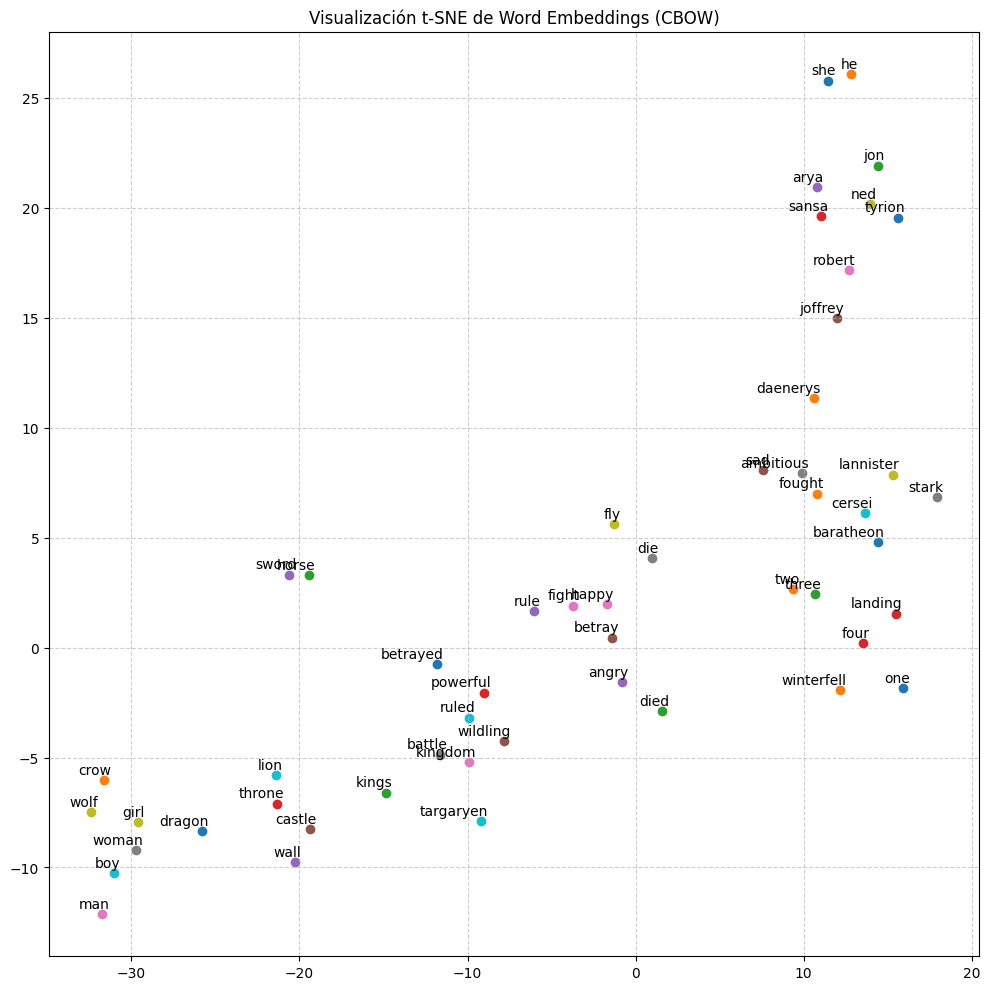

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# 9. VISUALIZACIÓN T-SNE
# ==========================================
print("\n--- Generando Visualización t-SNE ---")

# 1. Definimos la función de visualización (basada en el archivo proporcionado)
def visualize_tsne_embeddings(words, embeddings, word_index, filename=None):
    # Filtramos para asegurarnos de que las palabras existen en nuestro vocabulario
    words_present = [w for w in words if w in word_index]
    
    if not words_present:
        print("Ninguna de las palabras objetivo está en el vocabulario.")
        return
        
    indices = [word_index[word] for word in words_present]
    selected_embeddings = embeddings[indices]
    
    # La perplejidad debe ser menor que el número de muestras
    perplexity = min(5, len(words_present) - 1)
    
    # Aplicamos t-SNE para reducir a 2 dimensiones
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0)
    reduced_embeddings = tsne.fit_transform(selected_embeddings)
    
    # Dibujamos el gráfico
    plt.figure(figsize=(12, 12))
    for i, word in enumerate(words_present):
        plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], marker='o')
        plt.annotate(word, xy=(reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                     xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
    
    plt.title("Visualización t-SNE de Word Embeddings (CBOW)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if filename:
        plt.savefig(filename)
        print(f"Gráfico guardado como: {filename}")
    else:
        plt.show()

# 2. Leemos las palabras objetivo del archivo
# Asegúrate de que la ruta coincida con donde tienes el archivo en tu proyecto
ruta_target = os.path.join('mats', 'target_words_game_of_thrones.txt')

try:
    with open(ruta_target, 'r', encoding='utf-8') as f:
        # Leemos limpiando espacios y saltos de línea
        palabras_objetivo = [linea.strip().lower() for linea in f.readlines() if linea.strip()]
    
    print(f"Se han cargado {len(palabras_objetivo)} palabras para visualizar.")
    
    # 3. Llamamos a la función de visualización
    visualize_tsne_embeddings(palabras_objetivo, pesos_embeddings, tokenizer.word_index, filename="tsne_cbow.png")

except FileNotFoundError:
    print(f"No se ha encontrado el archivo en la ruta: {ruta_target}")